# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The E-Commerce Order Dataset](https://www.kaggle.com/datasets/emirhanakku/e-commerce-order-risk-classification-dataset/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('synthetic_ecommerce_order_risk_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,...,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,...,105.7,5,0,0,0,0,4.4,0,0,Normal
1,ORD-2025-006495,2025-11-26,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,...,528.2,4,0,0,0,0,4.8,0,0,Normal
2,ORD-2023-001721,2023-11-07,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,...,175.1,5,0,0,0,0,3.3,0,0,Normal
3,ORD-2024-009121,2024-05-28,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,...,271.4,3,0,0,0,0,4.2,1,0,Return Risk
4,ORD-2025-000361,2025-01-31,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,...,285.3,3,0,1,0,0,5.0,0,0,Normal


## last Five row

In [4]:
df.tail()

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,...,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
11995,ORD-2023-011965,2023-02-19,France,Mobile,Social Media,Credit Card,Garden,742,3,25.75,...,121.4,3,0,0,0,1,4.5,0,0,Normal
11996,ORD-2023-005192,2023-05-12,France,Mobile,Organic Search,Debit Card,Fashion,152,1,96.29,...,225.5,4,0,0,0,0,5.0,0,0,Normal
11997,ORD-2024-005391,2024-06-13,Germany,Mobile,Organic Search,Credit Card,Fashion,130,0,114.14,...,669.6,5,0,0,0,0,4.5,0,0,Normal
11998,ORD-2025-000861,2025-04-04,Poland,Desktop,Marketplace,PayPal,Fashion,203,1,21.60,...,229.4,5,0,0,0,0,4.4,0,0,Normal
11999,ORD-2024-007271,2024-05-23,Netherlands,Desktop,Organic Search,PayPal,Beauty,288,2,35.58,...,406.6,3,0,0,0,1,3.7,0,0,Normal


## Shape of our dataset

In [5]:
df.shape

(12000, 23)

## List out all columns

In [6]:
df.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

order_id                      object
order_date                    object
country                       object
device_type                   object
traffic_source                object
payment_method                object
product_category              object
customer_age_days              int64
previous_orders                int64
avg_order_value_eur          float64
order_value_eur              float64
quantity                       int64
discount_rate                float64
shipping_distance_km         float64
delivery_days_estimated        int64
late_delivery_risk             int64
address_mismatch               int64
high_risk_ip                   int64
customer_support_contacts      int64
review_score                 float64
is_returned                    int64
is_fraud                       int64
risk_label                    object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   12000 non-null  object 
 1   order_date                 12000 non-null  object 
 2   country                    12000 non-null  object 
 3   device_type                12000 non-null  object 
 4   traffic_source             12000 non-null  object 
 5   payment_method             12000 non-null  object 
 6   product_category           12000 non-null  object 
 7   customer_age_days          12000 non-null  int64  
 8   previous_orders            12000 non-null  int64  
 9   avg_order_value_eur        12000 non-null  float64
 10  order_value_eur            12000 non-null  float64
 11  quantity                   12000 non-null  int64  
 12  discount_rate              12000 non-null  float64
 13  shipping_distance_km       12000 non-null  flo

## Check Null Value

In [9]:
df.isnull().sum()

order_id                     0
order_date                   0
country                      0
device_type                  0
traffic_source               0
payment_method               0
product_category             0
customer_age_days            0
previous_orders              0
avg_order_value_eur          0
order_value_eur              0
quantity                     0
discount_rate                0
shipping_distance_km         0
delivery_days_estimated      0
late_delivery_risk           0
address_mismatch             0
high_risk_ip                 0
customer_support_contacts    0
review_score                 0
is_returned                  0
is_fraud                     0
risk_label                   0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,352.789083,1.943417,48.940278,61.053339,2.171833,0.146857,479.196567,4.058917,0.060000,0.048583,0.044167,0.200667,4.412433,0.092667,0.037250
std,237.556088,1.902590,28.716864,55.540429,1.625534,0.113934,330.305205,1.105312,0.237497,0.215004,0.205474,0.478803,0.545286,0.289977,0.189382
min,5.000000,0.000000,8.000000,5.000000,1.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.300000,0.000000,0.000000
25%,177.000000,1.000000,29.070000,26.617500,1.000000,0.060000,236.100000,3.000000,0.000000,0.000000,0.000000,0.000000,4.100000,0.000000,0.000000
50%,299.000000,1.000000,42.100000,45.335000,2.000000,0.120000,404.450000,4.000000,0.000000,0.000000,0.000000,0.000000,4.500000,0.000000,0.000000
75%,475.000000,3.000000,61.010000,75.952500,3.000000,0.210000,645.225000,5.000000,0.000000,0.000000,0.000000,0.000000,4.900000,0.000000,0.000000
max,1832.000000,13.000000,350.450000,810.750000,8.000000,0.750000,2589.700000,9.000000,1.000000,1.000000,1.000000,5.000000,5.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

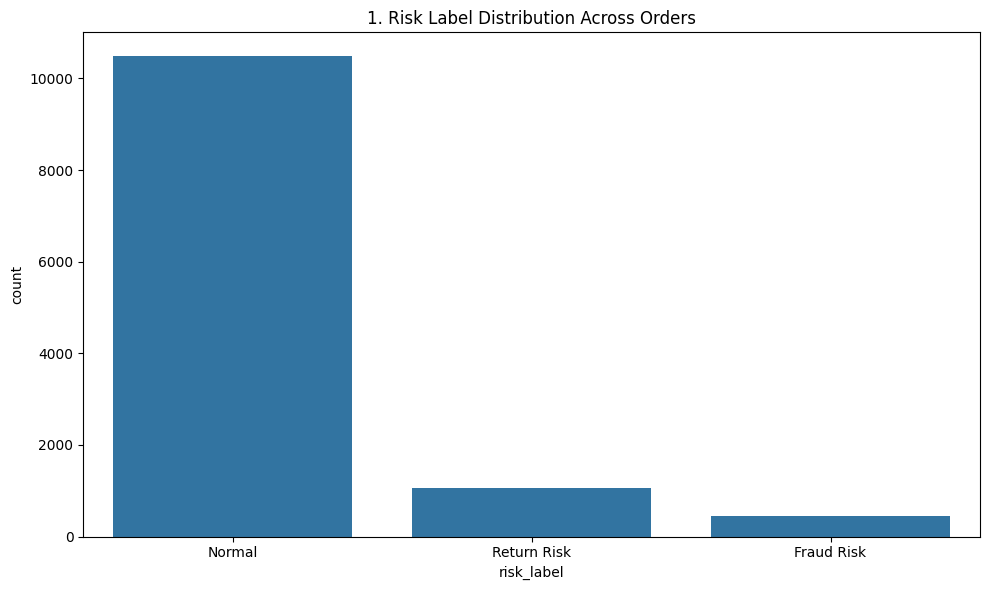

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='risk_label', order=df['risk_label'].value_counts().index)
plt.title(f'{plot_no}. Risk Label Distribution Across Orders')
show_fig()
plot_no += 1

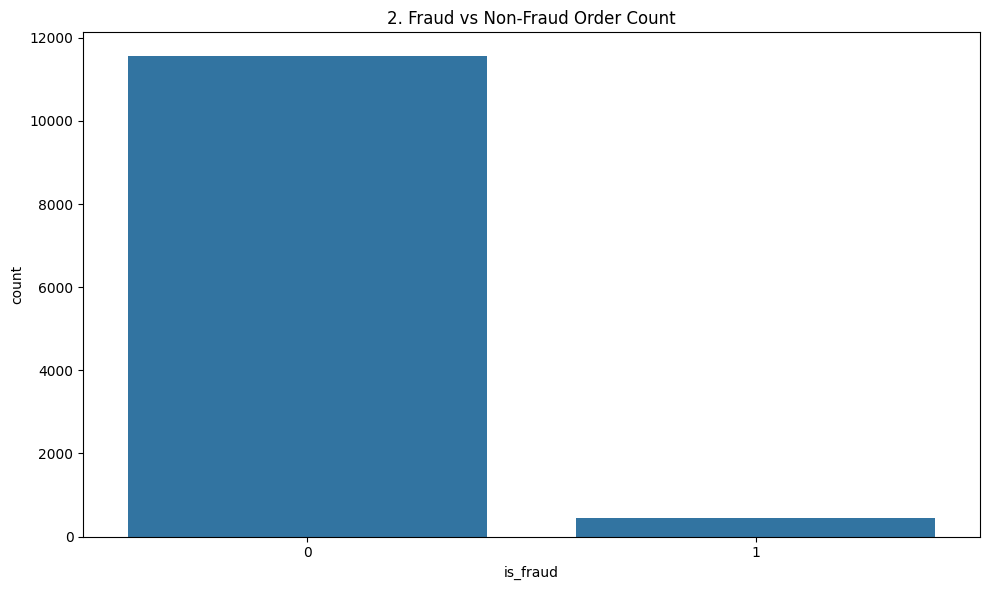

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='is_fraud')
plt.title(f'{plot_no}. Fraud vs Non-Fraud Order Count')
show_fig()
plot_no += 1

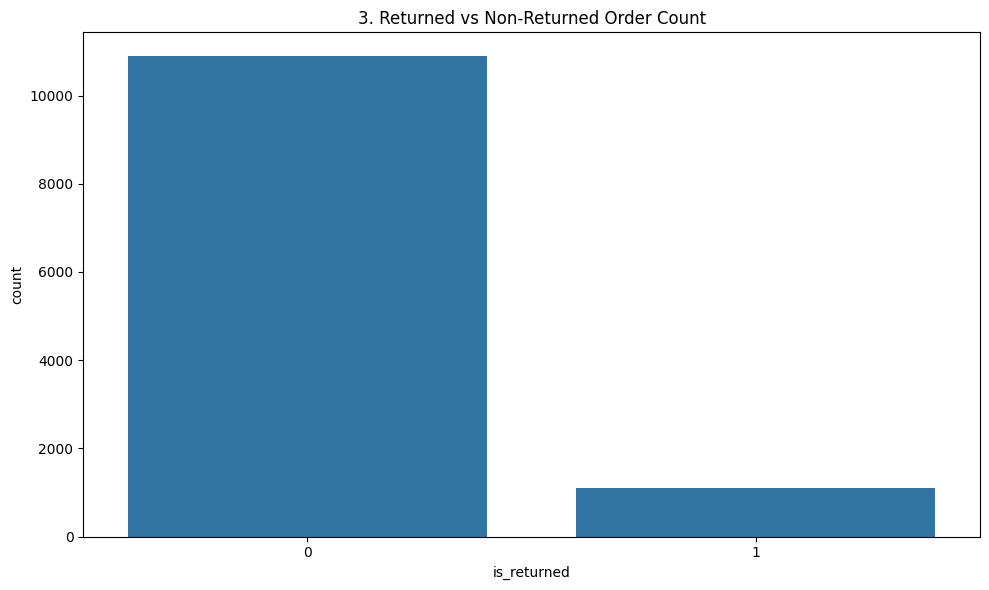

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='is_returned')
plt.title(f'{plot_no}. Returned vs Non-Returned Order Count')
show_fig()
plot_no += 1

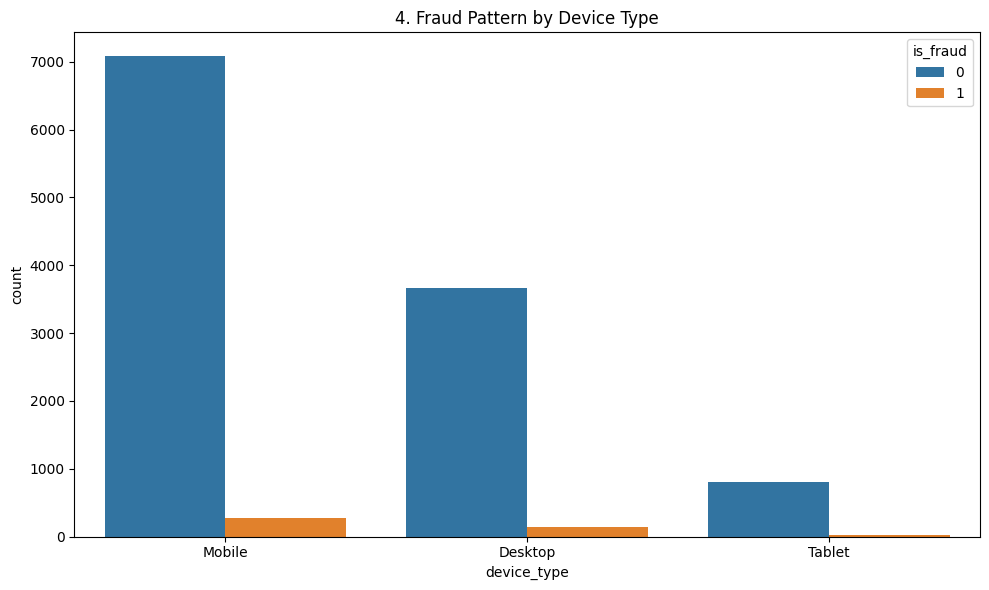

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='device_type', hue='is_fraud')
plt.title(f'{plot_no}. Fraud Pattern by Device Type')
show_fig()
plot_no += 1

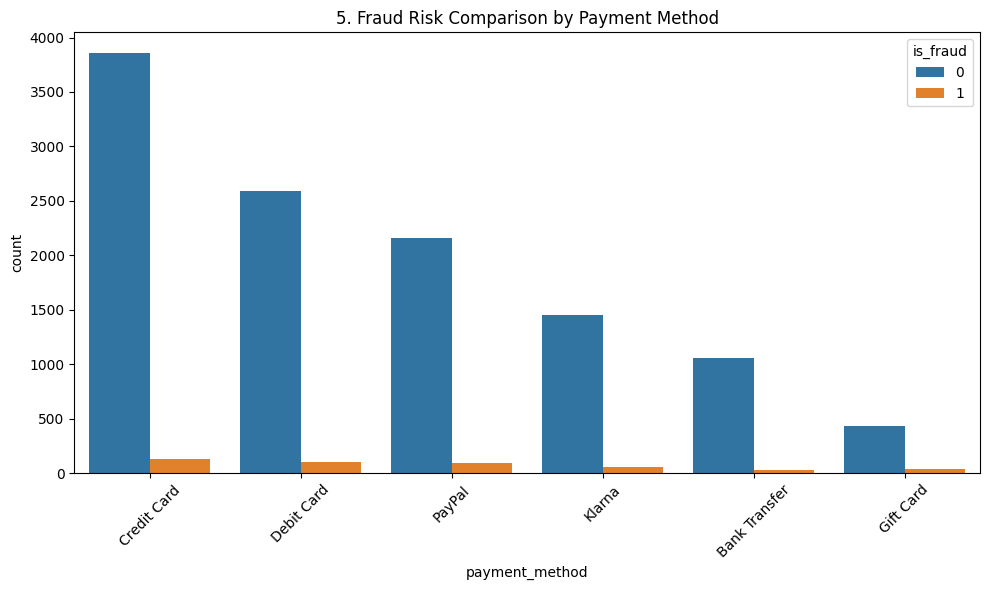

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='payment_method', hue='is_fraud', order=df['payment_method'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Fraud Risk Comparison by Payment Method')
show_fig()
plot_no += 1

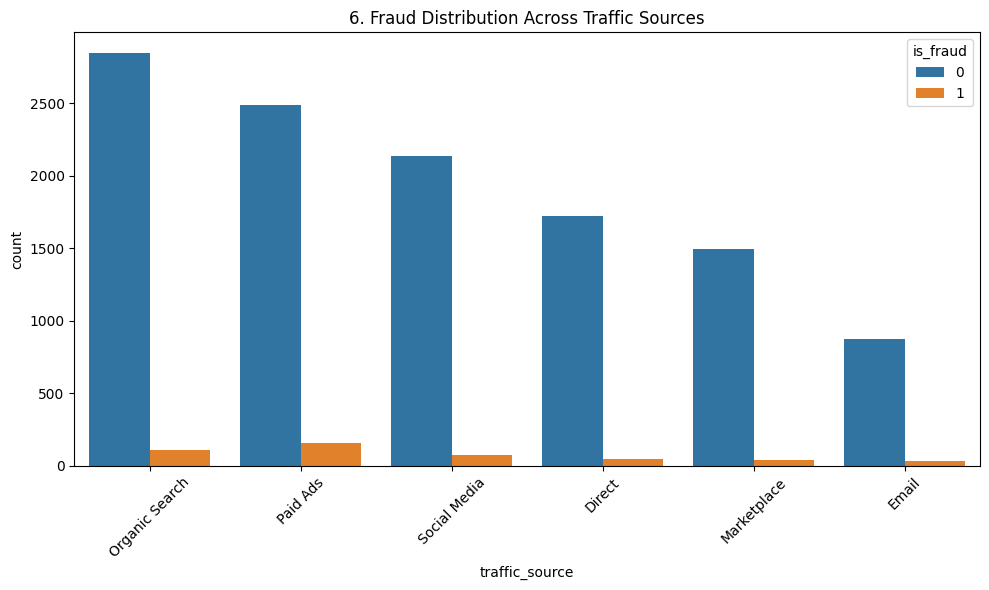

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='traffic_source', hue='is_fraud', order=df['traffic_source'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Fraud Distribution Across Traffic Sources')
show_fig()
plot_no += 1

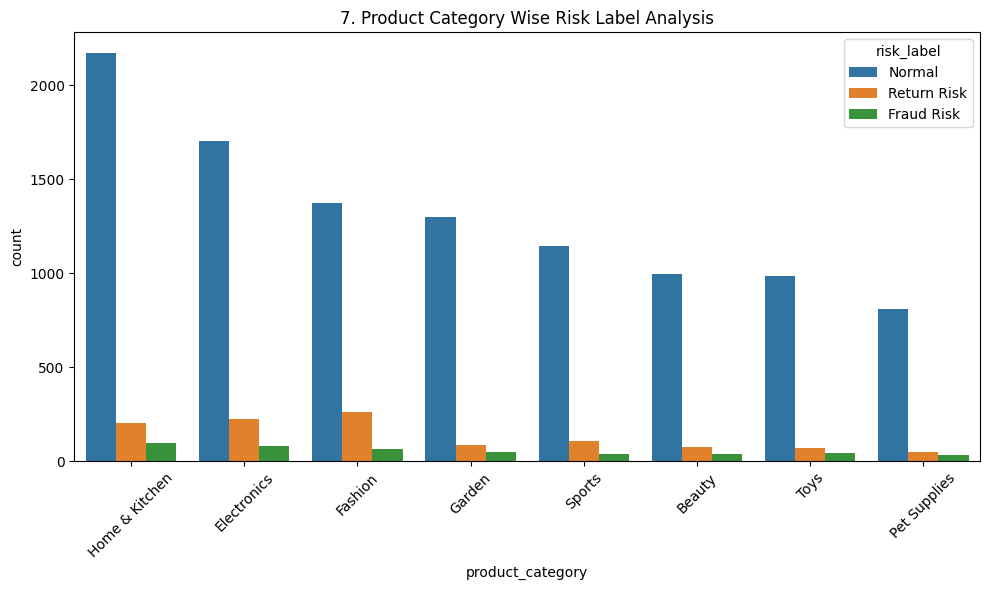

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='product_category', hue='risk_label', order=df['product_category'].value_counts().index)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Product Category Wise Risk Label Analysis')
show_fig()
plot_no += 1

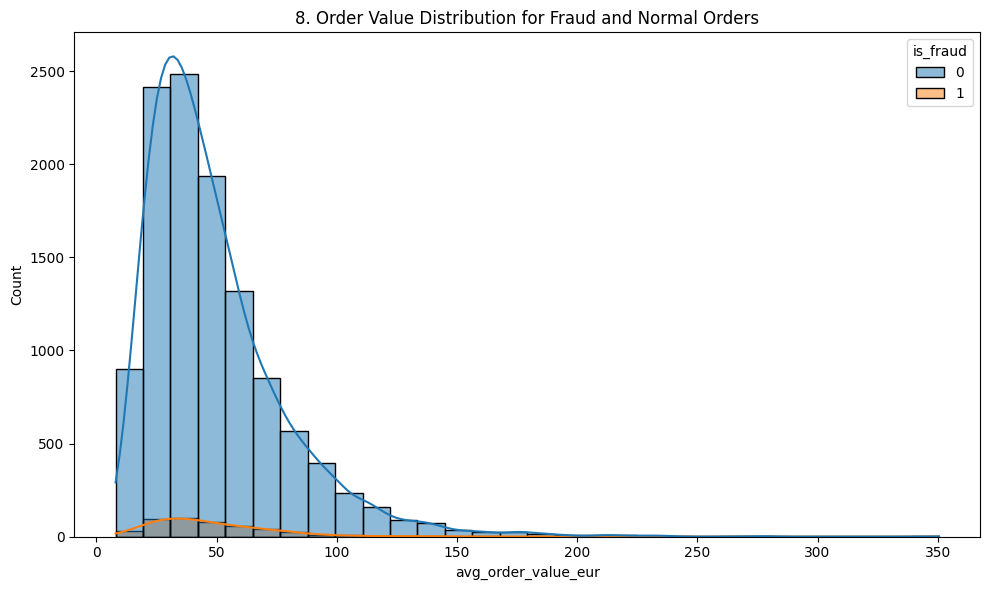

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='avg_order_value_eur', hue='is_fraud', kde=True, bins=30)
plt.title(f'{plot_no}. Order Value Distribution for Fraud and Normal Orders')
show_fig()
plot_no += 1

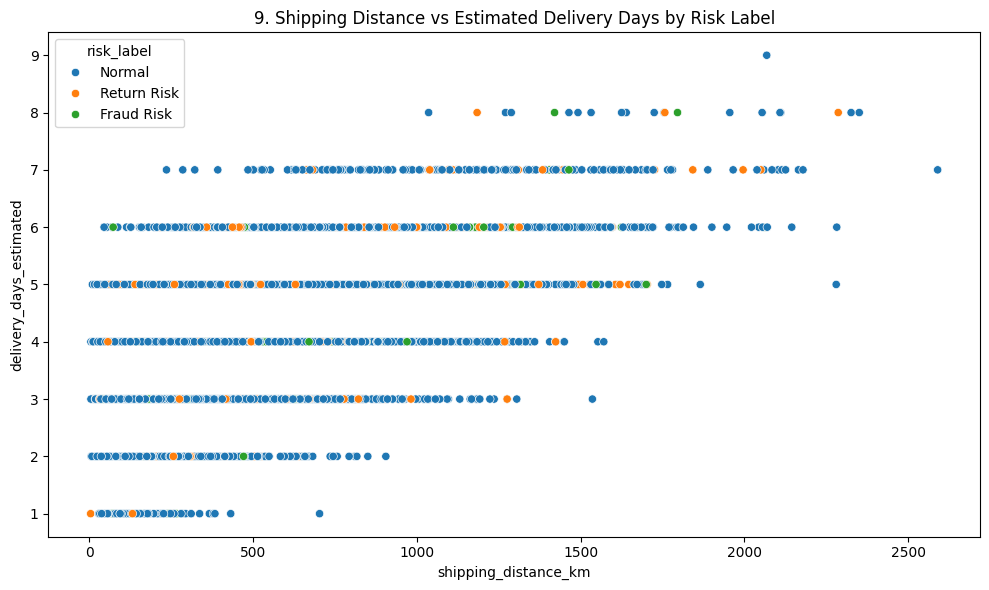

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='shipping_distance_km', y='delivery_days_estimated', hue='risk_label')
plt.title(f'{plot_no}. Shipping Distance vs Estimated Delivery Days by Risk Label')
show_fig()
plot_no += 1

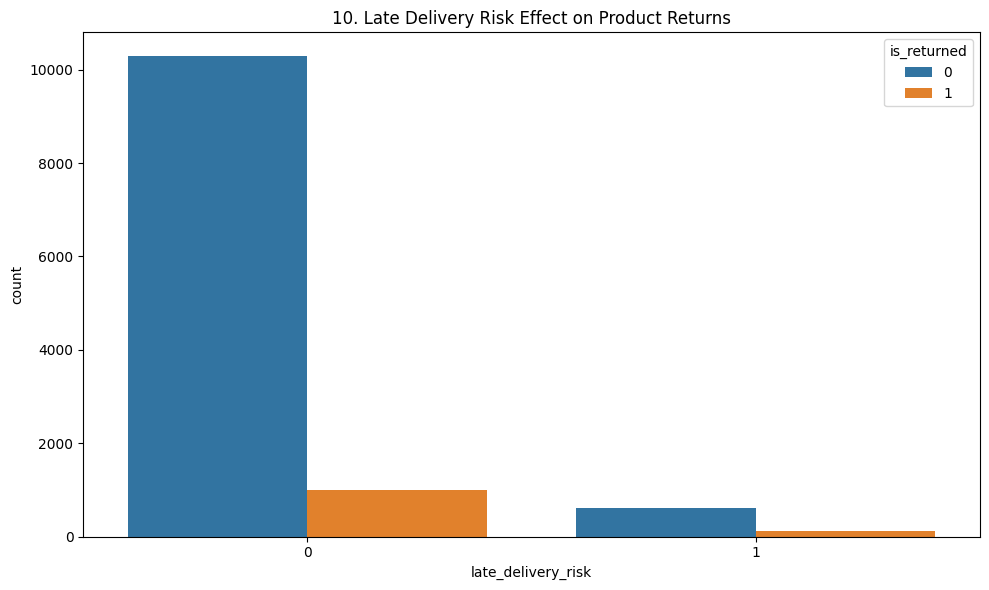

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='late_delivery_risk', hue='is_returned')
plt.title(f'{plot_no}. Late Delivery Risk Effect on Product Returns')
show_fig()
plot_no += 1

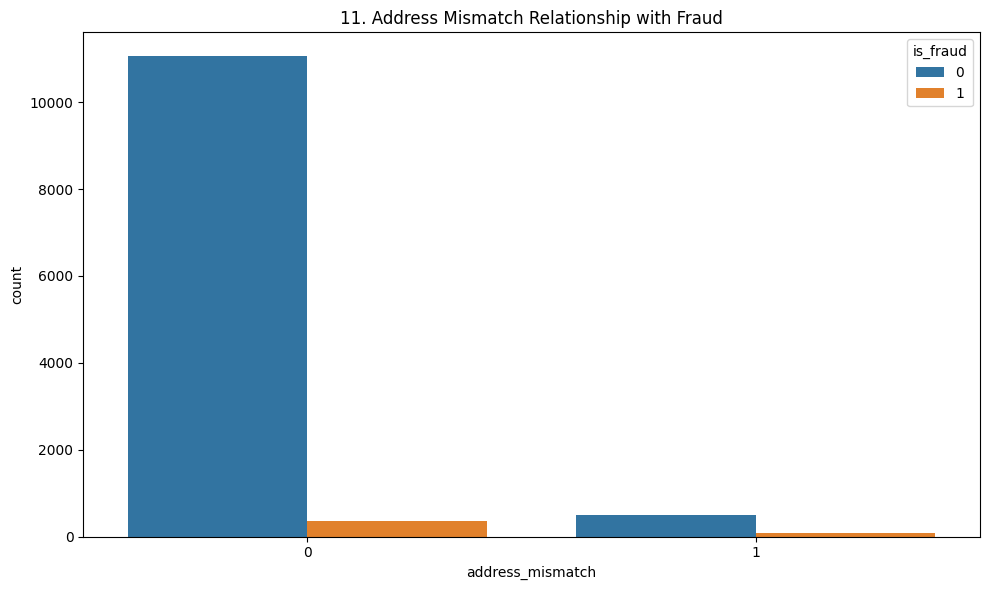

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='address_mismatch', hue='is_fraud')
plt.title(f'{plot_no}. Address Mismatch Relationship with Fraud')
show_fig()
plot_no += 1

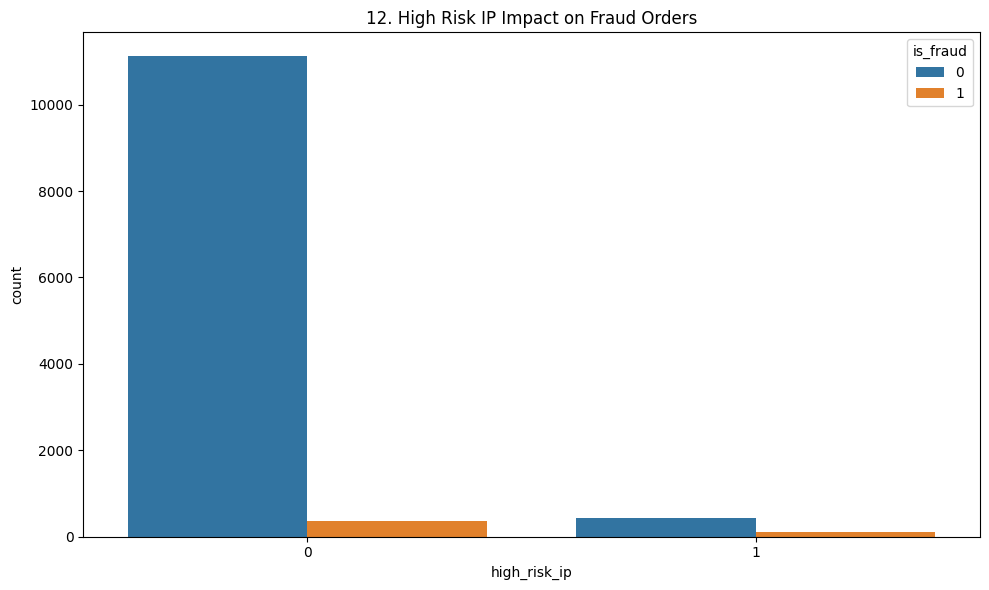

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='high_risk_ip', hue='is_fraud')
plt.title(f'{plot_no}. High Risk IP Impact on Fraud Orders')
show_fig()
plot_no += 1

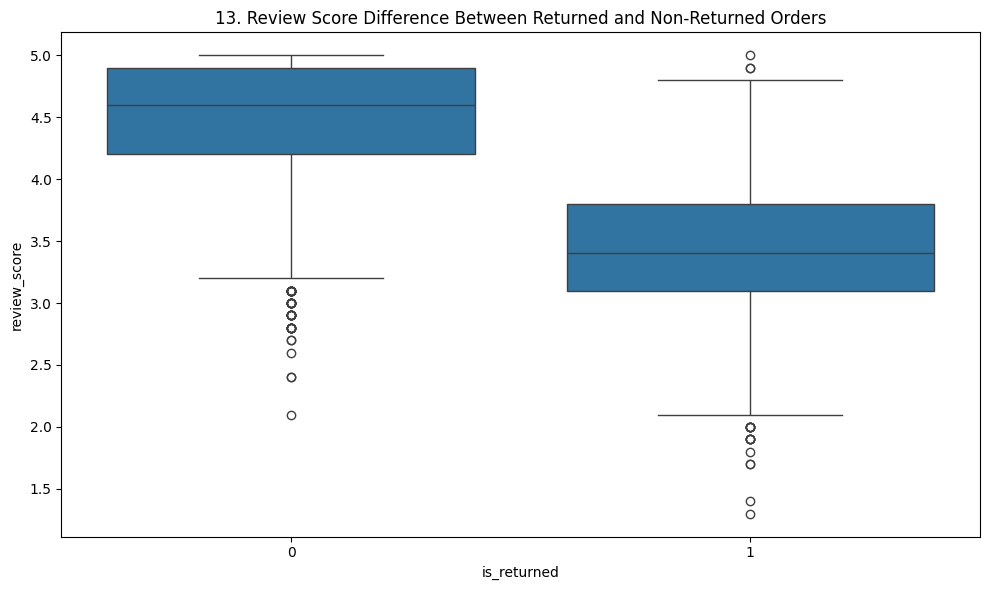

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='is_returned', y='review_score')
plt.title(f'{plot_no}. Review Score Difference Between Returned and Non-Returned Orders')
show_fig()
plot_no += 1

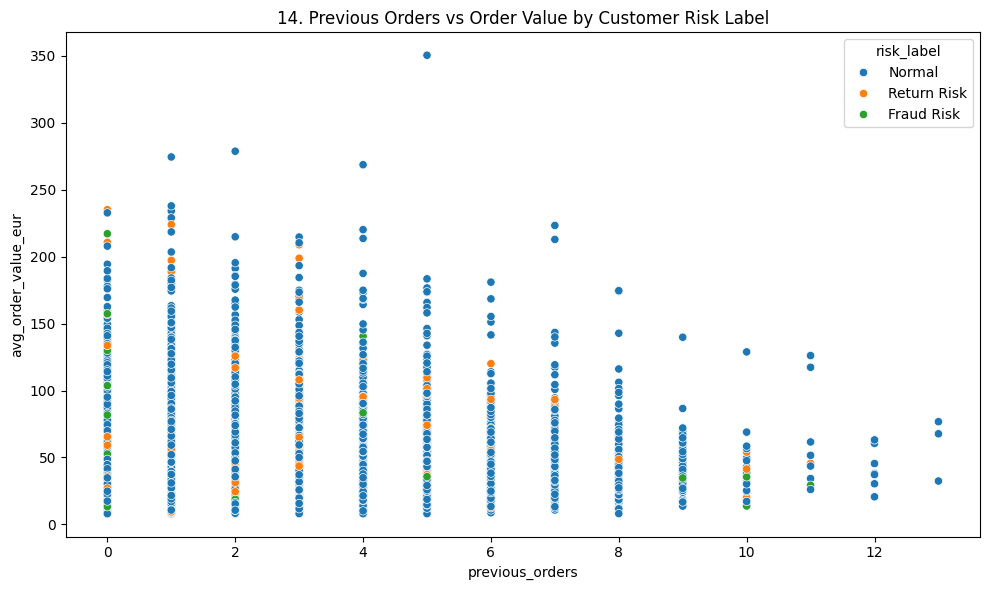

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='previous_orders', y='avg_order_value_eur', hue='risk_label')
plt.title(f'{plot_no}. Previous Orders vs Order Value by Customer Risk Label')
show_fig()
plot_no += 1

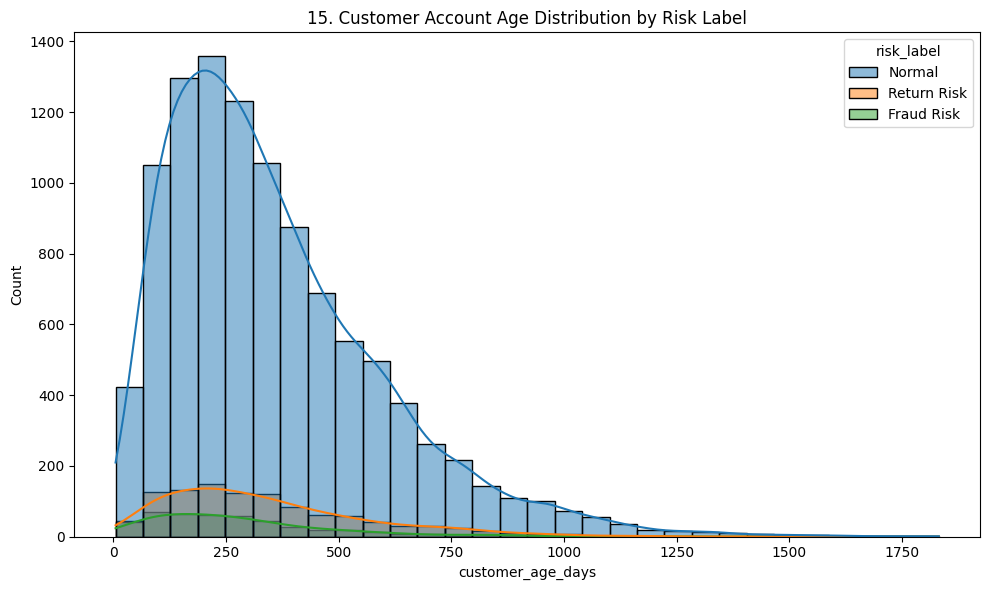

In [27]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='customer_age_days', hue='risk_label', kde=True, bins=30)
plt.title(f'{plot_no}. Customer Account Age Distribution by Risk Label')
show_fig()
plot_no += 1

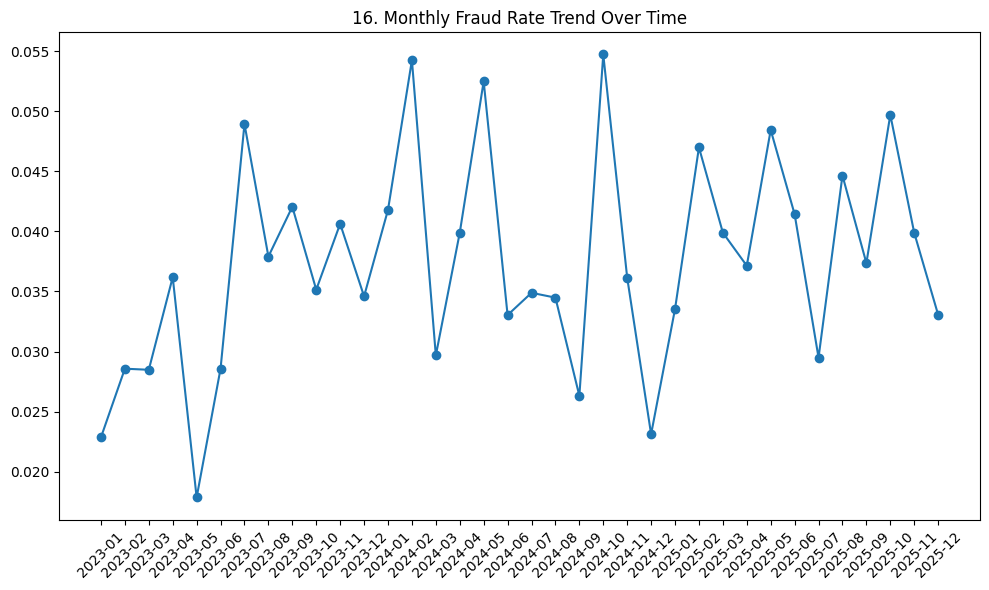

In [28]:
fig = plt.figure(figsize=(10,6))
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
monthly_fraud = df.groupby(df['order_date'].dt.to_period('M'))['is_fraud'].mean()
monthly_fraud.index = monthly_fraud.index.astype(str)
plt.plot(monthly_fraud.index, monthly_fraud.values, marker='o')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Monthly Fraud Rate Trend Over Time')
show_fig()
plot_no += 1

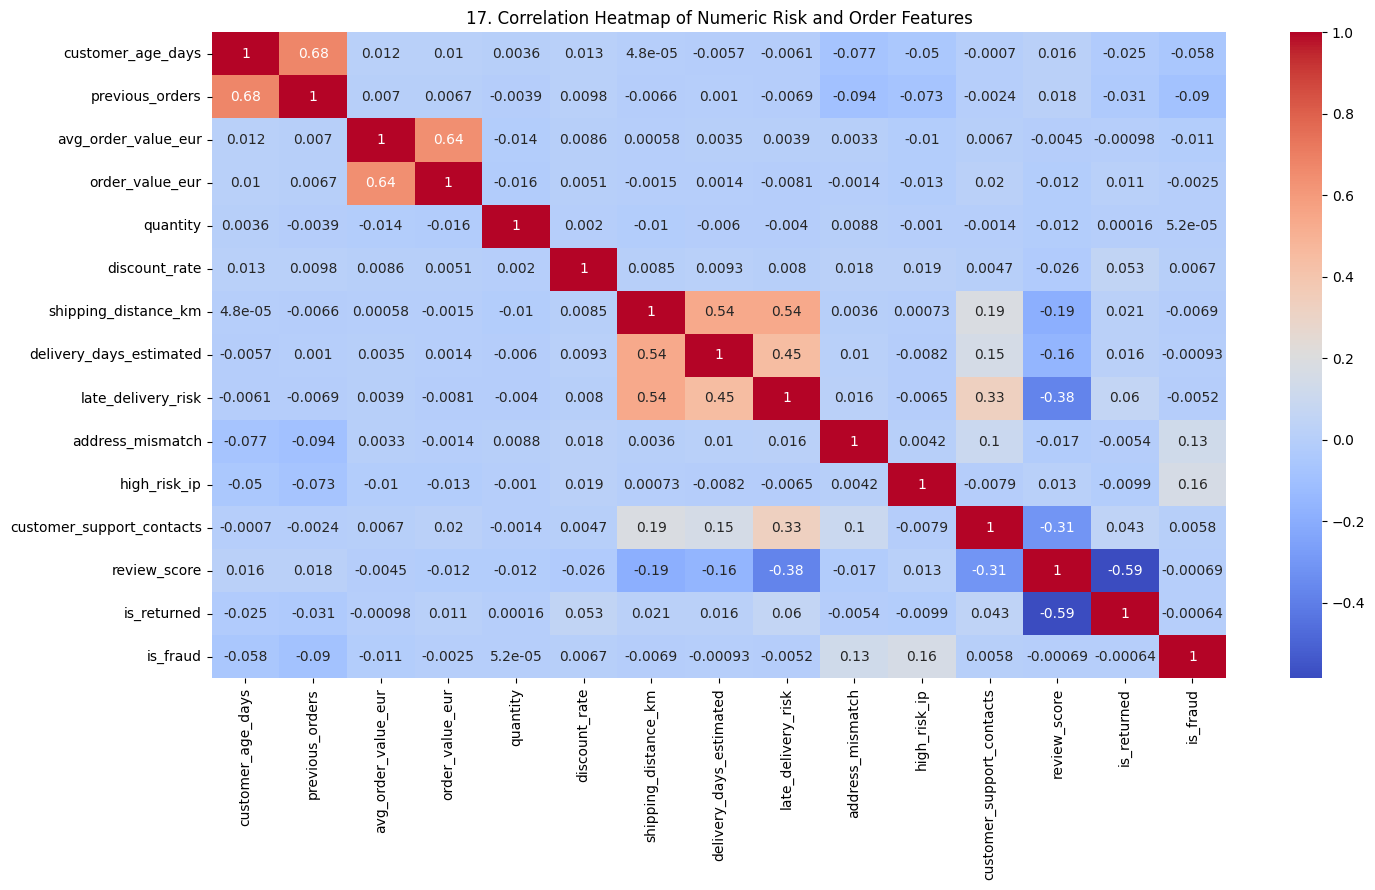

In [29]:
fig = plt.figure(figsize=(15, 9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Risk and Order Features')
show_fig()
plot_no += 1

# Model Training

## Select target column

In [30]:
target = 'is_fraud'

## Create X and y

In [31]:
X = df.drop(columns=[target, 'order_id', 'risk_label'], errors='ignore')
y = df[target]

## Convert order date into useful numeric features

In [32]:
X['order_date'] = pd.to_datetime(X['order_date'], errors='coerce')
X['order_year'] = X['order_date'].dt.year
X['order_month'] = X['order_date'].dt.month
X['order_day'] = X['order_date'].dt.day
X['order_dayofweek'] = X['order_date'].dt.dayofweek
X = X.drop(columns=['order_date'], errors='ignore')

## Split numeric and categorical columns

In [33]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

## Build preprocessing pipeline

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

## Train test split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Create supervised model

In [36]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

## Train model

In [37]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict test data

In [38]:
y_pred = model.predict(X_test)

## Print accuracy score

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.7829166666666667


## Print classification report

In [40]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.79      0.88      2311
           1       0.10      0.61      0.17        89

    accuracy                           0.78      2400
   macro avg       0.54      0.70      0.52      2400
weighted avg       0.95      0.78      0.85      2400



## Plot confusion matrix

<Figure size 1000x600 with 0 Axes>

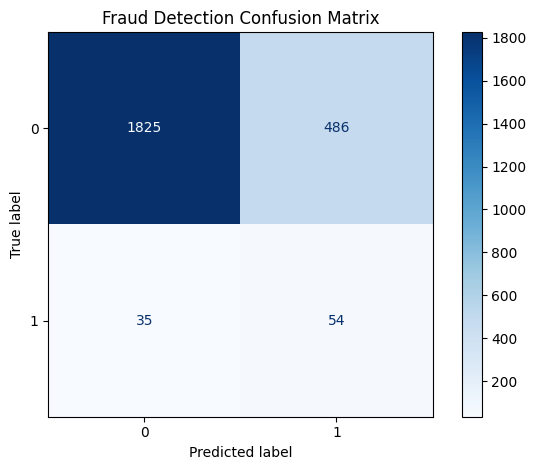

In [41]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Fraud Detection Confusion Matrix')
plt.tight_layout()
plt.show()